In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [3]:
image = cv2.imread('/Users/mirjalol/Downloads/img.png',
cv2.IMREAD_GRAYSCALE)
kernel = np.array([[1, 2, 1], [0, 0, 0], [-1,
-2, -1]])

In [4]:
convolved_image = cv2.filter2D(image, -1, kernel)

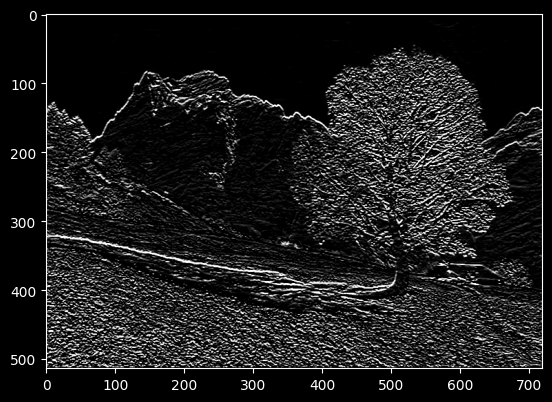

In [5]:
plt.imshow(convolved_image, cmap='gray')
plt.show()

In [13]:
def box_filt(n):
    if n <= 0 or n % 2 == 0:
        raise ValueError("Window size must be a positive odd integer.")
    kernel = np.ones((n, n), np.float32) / (n * n)
    return kernel

In [18]:
def apply_filters(image_input, box, filt_size):
    pad_size = int(np.ceil(filt_size / 2))

    image_padded = np.pad(
        image_input,
        pad_width=((pad_size, pad_size), (pad_size, pad_size)),
        mode='symmetric'
    )

    image_box = copy.deepcopy(image_input)

    row, column = image_input.shape

    for i in range(row):
        for j in range(column):
            patch_curr = image_padded[i:i + filt_size, j:j + filt_size]
            results_box = box * patch_curr
            image_box[i, j] = np.sum(results_box)

    return image_box

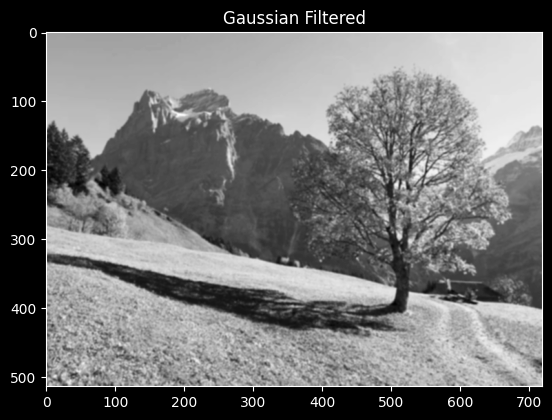

In [19]:
gaussian_filtered_image = cv2.GaussianBlur(image, (5, 5), 0)
plt.imshow(gaussian_filtered_image, cmap='gray')
plt.title('Gaussian Filtered')
plt.show()

In [30]:
def gauss_filt(n, sigma=1.0):
    if n <= 0 or n % 2 == 0:
        raise ValueError("Window size must be a positive odd integer.")
    ax = np.linspace(-(n - 1) / 2., (n - 1) / 2., n)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-0.5 * (np.square(xx) + np.square(yy)) / np.square(sigma))
    kernel = kernel / np.sum(kernel)
    return kernel

In [24]:
pip install opencv-python matplotlib numpy scikit-image

  Using cached numpy-2.0.2-cp39-cp39-macosx_14_0_arm64.whl.metadata (60 kB)
Using cached numpy-2.0.2-cp39-cp39-macosx_14_0_arm64.whl (5.3 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: /Users/mirjalol/PycharmProjects/JupyterProject1/.venv/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


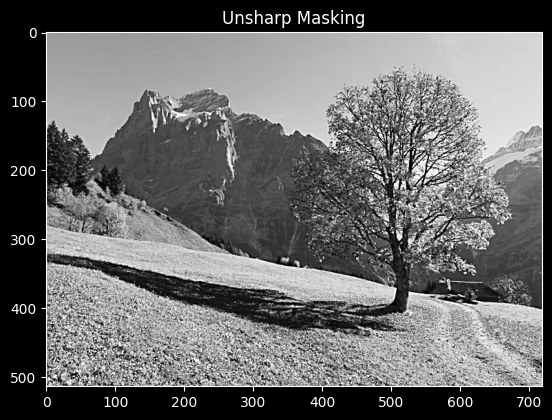

In [31]:
blurred = cv2.GaussianBlur(image, (9, 9), 10)
unsharp_image = cv2.addWeighted(image, 1.5, blurred, -0.5, 0)
plt.imshow(unsharp_image, cmap='gray')
plt.title('Unsharp Masking')
plt.show()

In [32]:
import copy
import cv2
import numpy as np
from matplotlib import pyplot as plt

In [33]:
def box_filt(n):
    if n <= 0 or n % 2 == 0:
        raise ValueError("Window size must be a positive odd integer.")
        kernel = np.ones((n, n), np.float32) / (n * n)
        return kernel

In [5]:
def apply_filters(image_input, box, filt_size):
    pad_size = int(np.ceil(filt_size/2))
    image_padded = np.pad(image_input, pad_width=((pad_size,pad_size),(pad_size, pad_size)), mode='symmetric')
    image_box = copy.deepcopy(image_input)
    row, column = image_input.shape
    for i in range(row):
        for j in range(column):
            patch_curr = image_padded[i:i + filt_size, j:j + filt_size]
            results_box = box * patch_curr
            image_box[i,j] = np.sum(results_box)
    return image_box
filt_size = 5
k = 2

In [3]:
def box_filt(filt_size):
    box = np.ones((filt_size, filt_size), np.float32) / (filt_size * filt_size)
    return box

In [ ]:
import cv2
import numpy as np

def box_filt(filt_size):
    box = np.ones((filt_size, filt_size), np.float32) / (filt_size ** 2)
    return box

def apply_filters(image_input, box, filt_size):
    h, w = image_input.shape
    pad = filt_size // 2
    image_padded = np.pad(image_input, pad, mode='reflect')
    image_box = np.zeros_like(image_input)

    for i in range(h):
        for j in range(w):
            patch_curr = image_padded[i:i + filt_size, j:j + filt_size]
            results_box = box * patch_curr
            image_box[i, j] = np.sum(results_box)
    return image_box

filt_size = 5
k = 1.5

image_input = cv2.imread('/Users/mirjalol/Downloads/img1.jpg', 0).astype('float32') / 255
box = box_filt(filt_size)
image_blur = apply_filters(image_input, box, filt_size)
image_diff = image_input - image_blur
image_sharp = np.clip(image_input + k * image_diff, 0, 1)

cv2.imshow('sharpen image', image_sharp)
cv2.waitKey(0)
cv2.destroyAllWindows()